In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [18]:
ratings = pd.read_csv('../data/ml-latest-small/ratings.csv')
movies = pd.read_csv('../data/ml-latest-small/movies.csv')

In [19]:
print(ratings.head(20))
print("=======================")
print("Missing Values: ")
print(ratings.isnull().sum())   # Missing Values
sns.set_theme(style="whitegrid")
print("=======================")
print("Total:")
print(f"Total Ratings: {len(ratings)}")
print(f"Total Movies: {len(movies)}")

    userId  movieId  rating  timestamp
0        1        1     4.0  964982703
1        1        3     4.0  964981247
2        1        6     4.0  964982224
3        1       47     5.0  964983815
4        1       50     5.0  964982931
5        1       70     3.0  964982400
6        1      101     5.0  964980868
7        1      110     4.0  964982176
8        1      151     5.0  964984041
9        1      157     5.0  964984100
10       1      163     5.0  964983650
11       1      216     5.0  964981208
12       1      223     3.0  964980985
13       1      231     5.0  964981179
14       1      235     4.0  964980908
15       1      260     5.0  964981680
16       1      296     3.0  964982967
17       1      316     3.0  964982310
18       1      333     5.0  964981179
19       1      349     4.0  964982563
Missing Values: 
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
Total:
Total Ratings: 100836
Total Movies: 9742


In [20]:
df = pd.merge(ratings, movies, on="movieId")
print(df.head())

   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


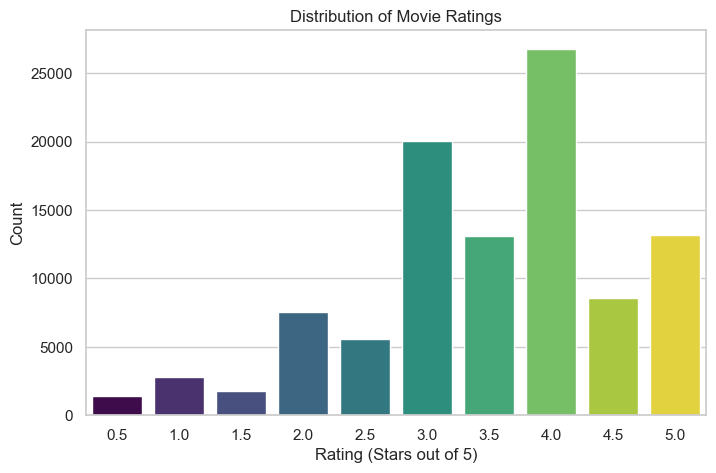

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x="rating", data=df, palette="viridis", hue="rating", legend=False)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating (Stars out of 5)')
plt.ylabel('Count')
plt.show()

Note the Spike at 4.0, People mostly rate movies they liked.

In [22]:
movie_stats = df.groupby('title').agg({'rating' : ['count', 'mean']})
movie_stats.columns = ['rating_count', 'rating_mean']
print(movie_stats.sort_values('rating_count', ascending=False).head(20))
print("===================")
print(movie_stats.sort_values('rating_count', ascending=False).tail(20))

                                                    rating_count  rating_mean
title                                                                        
Forrest Gump (1994)                                          329     4.164134
Shawshank Redemption, The (1994)                             317     4.429022
Pulp Fiction (1994)                                          307     4.197068
Silence of the Lambs, The (1991)                             279     4.161290
Matrix, The (1999)                                           278     4.192446
Star Wars: Episode IV - A New Hope (1977)                    251     4.231076
Jurassic Park (1993)                                         238     3.750000
Braveheart (1995)                                            237     4.031646
Terminator 2: Judgment Day (1991)                            224     3.970982
Schindler's List (1993)                                      220     4.225000
Fight Club (1999)                                            218

A considerable amount of movies have very less ratings

In [23]:
min_ratings = 10
less_than_10 = len(movie_stats[movie_stats['rating_count'] < min_ratings])
more_than_or_equal_to_10 = len(movie_stats[movie_stats['rating_count'] >= min_ratings])

print(f"Movies with less than {min_ratings} ratings: {less_than_10}")
print(f"Movies with {min_ratings} or more ratings: {more_than_or_equal_to_10}")
total_movies = len(movie_stats)
print(f"Percentage of movies with < 10 ratings: {(less_than_10/total_movies)*100:.2f}%")


Movies with less than 10 ratings: 7450
Movies with 10 or more ratings: 2269
Percentage of movies with < 10 ratings: 76.65%


In [24]:
popular_movies = movie_stats[movie_stats['rating_count'] >= min_ratings].index
filtered_df = df[df['title'].isin(popular_movies)]
print(f"Original ratings count: {len(df)}")
print(f"Clean ratings count: {len(filtered_df)}")
print(f"Data retained: {(len(filtered_df)/len(df))*100:.2f}%")

Original ratings count: 100836
Clean ratings count: 81120
Data retained: 80.45%


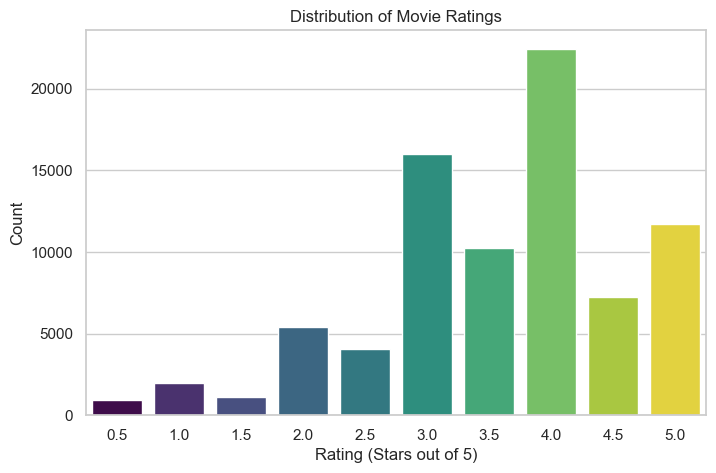

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x="rating", data=filtered_df, palette="viridis", hue="rating", legend=False)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating (Stars out of 5)')
plt.ylabel('Count')
plt.show()

Checking for Users who have rated very few movies.

In [27]:
user_stats = filtered_df.groupby('userId').agg({'rating' : 'count'})
print(user_stats.sort_values(by="rating"))

        rating
userId        
175          7
578         11
324         13
598         14
320         15
...        ...
448       1017
474       1077
68        1086
599       1368
414       1634

[610 rows x 1 columns]


Number of ratings by some users dropped to less than 15 now after removing some movies.

In [28]:
min_user_ratings = 15

# Count how many ratings each user has left in the filtered_df
user_counts = filtered_df['userId'].value_counts()

# Get the list of users who still meet the threshold
valid_users = user_counts[user_counts >= min_user_ratings].index

# Further filter the dataframe
final_df = filtered_df[filtered_df['userId'].isin(valid_users)]

print(f"Users before filter: {filtered_df['userId'].nunique()}")
print(f"Users after filter: {final_df['userId'].nunique()}")
print(f"Ratings remaining: {len(final_df)} ({(len(final_df)/len(df))*100:.2f}% of original)")

Users before filter: 610
Users after filter: 606
Ratings remaining: 81075 (80.40% of original)


We check again if any movie has less than 10 ratings

In [29]:
# Recalculate the rating counts per movie using the newly filtered dataset
new_movie_counts = final_df['title'].value_counts()

# Find how many movies now have less than the minimum ratings (10)
movies_below_10 = (new_movie_counts < 10).sum()

print(f"Movies that dropped below 10 ratings: {movies_below_10}")

# See the ones that dropped and their new counts
if movies_below_10 > 0:
    print("\nExamples of movies that dropped:")
    print(new_movie_counts[new_movie_counts < 10].head())

Movies that dropped below 10 ratings: 1

Examples of movies that dropped:
title
Lake House, The (2006)    9
Name: count, dtype: int64


In [31]:
user_stats = final_df.groupby('userId').agg({'rating' : 'count'})
print(user_stats.sort_values(by="rating"))

        rating
userId        
544         15
499         15
320         15
548         16
547         17
...        ...
448       1017
474       1077
68        1086
599       1368
414       1634

[606 rows x 1 columns]


Each user now has more than 15 ratings and each movie has more than 10 ratings to it's name.

Extracting the Release Year from the Title

In [35]:
# Extract the year using regex and create a new column
final_df['year'] = final_df['title'].str.extract(r'\((\d{4})\)')
# Clean the title by removing the year
final_df['clean_title'] = final_df['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True)
print(final_df.head())

   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  year           clean_title  
0  Adventure|Animation|Children|Comedy|Fantasy  1995             Toy Story  
1                               Comedy|Romance  1995      Grumpier Old Men  
2                        Action|Crime|Thriller  1995                  Heat  
3                             Mystery|Thriller  1995  Seven (a.k.a. Se7en)  
4                       Crime|Mystery|Thriller  1995   Usual Suspects, The  


C:\Users\apbah\AppData\Local\Temp\ipykernel_18328\1184716723.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['year'] = final_df['title'].str.extract(r'\((\d{4})\)')
C:\Users\apbah\AppData\Local\Temp\ipykernel_18328\1184716723.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['clean_title'] = final_df['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True)


Genre Analysis

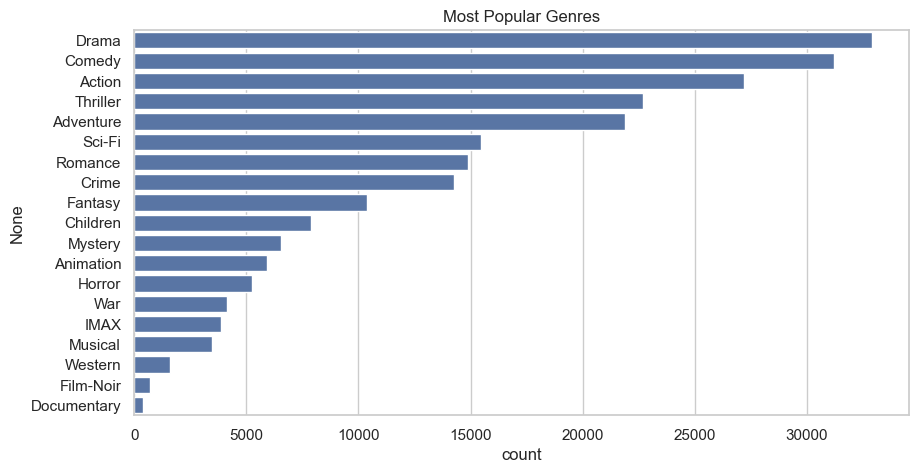

In [36]:
# Splitting by pipe
all_genres = final_df['genres'].str.split('|', expand=True).stack()
plt.figure(figsize=(10,5))
sns.countplot(y=all_genres, order=all_genres.value_counts().index)
plt.title("Most Popular Genres")
plt.show()

Check Matrix Sparsity

In [37]:
num_users = final_df['userId'].nunique()
num_movies = final_df['movieId'].nunique()
num_ratings = len(final_df)
matrix_size = num_users * num_movies
sparsity = (1.0 - (num_ratings / matrix_size)) * 100
print(f"Matrix Sparsity is: {sparsity:.2f}%")

Matrix Sparsity is: 94.11%


Dropping the title column

In [38]:
final_df = final_df.drop('title', axis=1)

In [39]:
print(final_df)

        userId  movieId  rating   timestamp  \
0            1        1     4.0   964982703   
1            1        3     4.0   964981247   
2            1        6     4.0   964982224   
3            1       47     5.0   964983815   
4            1       50     5.0   964982931   
...        ...      ...     ...         ...   
100818     610   159093     3.0  1493847704   
100829     610   164179     5.0  1493845631   
100830     610   166528     4.0  1493879365   
100833     610   168250     5.0  1494273047   
100834     610   168252     5.0  1493846352   

                                             genres  year  \
0       Adventure|Animation|Children|Comedy|Fantasy  1995   
1                                    Comedy|Romance  1995   
2                             Action|Crime|Thriller  1995   
3                                  Mystery|Thriller  1995   
4                            Crime|Mystery|Thriller  1995   
...                                             ...   ...   
100818  

In [40]:
final_df.to_csv('../data/cleaned_movie_ratings.csv', index=False)